# Approach 02  BI Prune + SVD Bridge Repair

Hard-remove the k lowest-BI layers, insert one ridge-fit affine bridge across the gap.

## Setup  install & versions

In [1]:
# Setup  install & versions
!pip install -q transformers datasets accelerate pandas matplotlib scipy

import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

device = "cpu"
print("device:", device)


zsh:1: command not found: pip


/Users/sumitjha/Downloads/nlp-layer-reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.1
Transformers: 5.18.0
device: cpu


## Reproducibility  seeds

In [2]:
# Reproducibility  seeds
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Models

In [3]:
# Models
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_IDS = [
    "openai-community/gpt2",
    "HuggingFaceTB/SmolLM-135M",
]

tokenizers = {}
for mid in MODEL_IDS:
    tok = AutoTokenizer.from_pretrained(mid)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tokenizers[mid] = tok


## Dataset

In [4]:
# Dataset
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")

def join_nonempty(split):
    return "\n\n".join(x for x in split["text"] if x and x.strip())

train_text = join_nonempty(dataset["train"])[:300000]
validation_text = join_nonempty(dataset["validation"])[:100000]
test_text = join_nonempty(dataset["test"])[:100000]
print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## Helpers  model architecture

In [5]:
# Helpers  model architecture
def get_layers(model):
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    return model.model.layers

def set_layers(model, blocks):
    blocks = torch.nn.ModuleList(blocks)
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        model.transformer.h = blocks
        model.config.n_layer = len(blocks)
    else:
        model.model.layers = blocks
        model.config.num_hidden_layers = len(blocks)
    return model

def load_fresh_model(model_id):
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model.config.use_cache = False
    model.eval()
    return model

def hidden_size(model):
    cfg = model.config
    return getattr(cfg, "n_embd", None) or cfg.hidden_size


## Metrics  PPL / params / latency

In [6]:
# Metrics  PPL / params / latency
import math, time, gc

EVAL_BLOCK_SIZE = 256
EVAL_TOKENS = 3000

def calculate_ppl(model, text, model_id, block_size=EVAL_BLOCK_SIZE, max_tokens=EVAL_TOKENS):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
    if max_tokens is not None:
        ids = ids[:max_tokens]
    n_blocks = len(ids) // block_size
    total_nll, total_tokens = 0.0, 0
    with torch.no_grad():
        for i in range(n_blocks):
            x = ids[i*block_size:(i+1)*block_size].unsqueeze(0).to(device)
            out = model(input_ids=x, labels=x, use_cache=False)
            c = x.numel() - 1
            total_nll += out.loss.item() * c
            total_tokens += c
    return math.exp(total_nll / total_tokens)

def parameter_count(model):
    return sum(p.numel() for p in model.parameters())

def measure_latency(model, text, model_id, seq_len=256, repeat=10):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text, return_tensors="pt", add_special_tokens=False)["input_ids"][:, :seq_len].to(device)
    with torch.no_grad():
        for _ in range(3):
            _ = model(ids, use_cache=False)
        t0 = time.perf_counter()
        for _ in range(repeat):
            _ = model(ids, use_cache=False)
        t1 = time.perf_counter()
    return 1000.0 * (t1 - t0) / repeat

def free_model(m):
    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Step 1  Block-Influence profile

In [7]:
# Step 1  Block-Influence profile
import torch.nn.functional as F

def block_influence(model, model_id, text, n_chars=2000):
    model.eval()
    tok = tokenizers[model_id]
    ids = tok(text[:n_chars], return_tensors="pt", add_special_tokens=False).to(device)
    with torch.no_grad():
        out = model(**ids, output_hidden_states=True, use_cache=False)
    hs = out.hidden_states
    return [1.0 - F.cosine_similarity(hs[i].float(), hs[i+1].float(), dim=-1).mean().item()
            for i in range(len(hs) - 1)]

def redundant_order(model_id, text=train_text):
    m = load_fresh_model(model_id).to(device)
    bis = block_influence(m, model_id, text)
    free_model(m)
    return sorted(range(len(bis)), key=lambda i: bis[i]), bis


## Step 1  Hard removal (baseline op)

In [8]:
# Step 1  Hard removal (baseline op)
def hard_remove(model_id, indices):
    model = load_fresh_model(model_id)
    blocks = list(get_layers(model))
    kept = [b for i, b in enumerate(blocks) if i not in set(indices)]
    set_layers(model, kept)
    for i, layer in enumerate(get_layers(model)):
        if hasattr(layer, "layer_idx"):
            layer.layer_idx = i
        if hasattr(layer, "self_attn") and hasattr(layer.self_attn, "layer_idx"):
            layer.self_attn.layer_idx = i
    return model


## Step 2  Fit affine/SVD bridge

In [9]:
# Step 2  Fit affine/SVD bridge

def fit_affine(X, Y, ridge=1e-4):
    n, d = X.shape
    X_aug = torch.cat([X, torch.ones(n, 1, dtype=X.dtype)], dim=1)
    W = torch.linalg.solve(X_aug.T @ X_aug + ridge * torch.eye(d + 1), X_aug.T @ Y)
    return W[:-1].T.contiguous(), W[-1].contiguous()

def collect_gap_io(model, model_id, lo, hi, text, n_chars=1200):
    tok = tokenizers[model_id]
    ids = tok(text[:n_chars], return_tensors="pt", add_special_tokens=False).to(device)
    blocks = get_layers(model)
    Xs, Ys = [], []
    def grab_in(m, a): Xs.append(a[0].detach().float().reshape(-1, a[0].shape[-1]).cpu())
    def grab_out(m, a, o):
        o = o[0] if isinstance(o, tuple) else o
        Ys.append(o.detach().float().reshape(-1, o.shape[-1]).cpu())
    hd = [blocks[lo].register_forward_pre_hook(grab_in), blocks[hi].register_forward_hook(grab_out)]
    with torch.no_grad():
        model(**ids, use_cache=False)
    for h in hd: h.remove()
    return torch.cat(Xs), torch.cat(Ys)

class AffineBridge(torch.nn.Module):
    def __init__(self, A, b):
        super().__init__()
        self.linear = torch.nn.Linear(A.shape[0], A.shape[0], bias=True).to(dtype=torch.get_default_dtype())
        with torch.no_grad():
            self.linear.weight.copy_(A); self.linear.bias.copy_(b)
    def forward(self, hidden_states, *args, **kwargs):
        x = hidden_states[0] if isinstance(hidden_states, tuple) else hidden_states
        return self.linear(x)


## Results  sweep & table

In [10]:
# Results  sweep & table

def prune_and_bridge(model_id, target):
    m0 = load_fresh_model(model_id).to(device)
    lo, hi = min(target), max(target)
    X, Y = collect_gap_io(m0, model_id, lo, hi, train_text)
    free_model(m0)
    A, b = fit_affine(X, Y)
    m = load_fresh_model(model_id)
    blocks = list(get_layers(m))
    kept = [b for i, b in enumerate(blocks) if i not in set(target)]
    pos = lo
    kept = kept[:pos] + [AffineBridge(A, b).to(next(m.parameters()).dtype)] + kept[pos:]
    return set_layers(m, kept)

rows = []
for mid in MODEL_IDS:
    order, _ = redundant_order(mid)
    for k in [1, 2, 3, 4]:
        t = sorted(order[:k])
        m_hard = hard_remove(mid, t).to(device)
        rows.append({"model": mid, "k": k, "method": "hard_remove",
                     "ppl": calculate_ppl(m_hard, validation_text, mid)})
        free_model(m_hard)
        m = prune_and_bridge(mid, t).to(device)
        rows.append({"model": mid, "k": k, "method": "hard_remove+bridge",
                     "ppl": calculate_ppl(m, validation_text, mid)})
        free_model(m)
        print(mid, k, t, rows[-1]["ppl"])


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 30160.19it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16831.81it/s]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (22056 > 1024). Running this sequence through the model will result in indexing errors


...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 12646.33it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10834.08it/s]

HuggingFaceTB/SmolLM-135M 4 [2, 4, 5, 27] 102067148.70937608


## Results  table & curves

                        model  k              method           ppl
0       openai-community/gpt2  1         hard_remove  4.575909e+01
1       openai-community/gpt2  1  hard_remove+bridge  4.542849e+03
2       openai-community/gpt2  2         hard_remove  4.795011e+01
3       openai-community/gpt2  2  hard_remove+bridge  9.414865e+03
4       openai-community/gpt2  3         hard_remove  1.218076e+02
5       openai-community/gpt2  3  hard_remove+bridge  9.314235e+03
6       openai-community/gpt2  4         hard_remove  9.432313e+02
7       openai-community/gpt2  4  hard_remove+bridge  9.461714e+03
8   HuggingFaceTB/SmolLM-135M  1         hard_remove  1.991507e+01
9   HuggingFaceTB/SmolLM-135M  1  hard_remove+bridge  1.857062e+08
10  HuggingFaceTB/SmolLM-135M  2         hard_remove  2.611918e+01
11  HuggingFaceTB/SmolLM-135M  2  hard_remove+bridge  9.071653e+07
12  HuggingFaceTB/SmolLM-135M  3         hard_remove  2.993165e+01
13  HuggingFaceTB/SmolLM-135M  3  hard_remove+bridge  9.756549

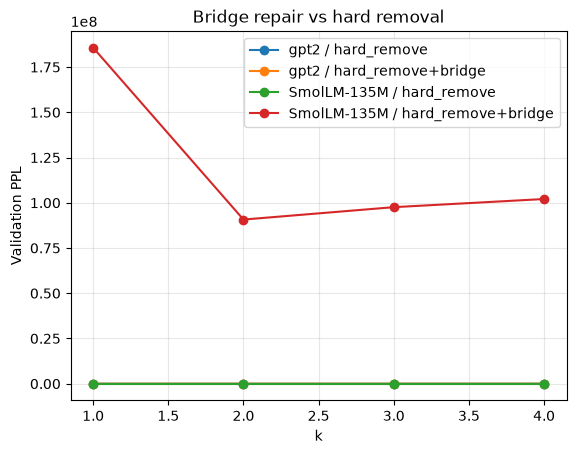

In [11]:
# Results  table & curves

import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(rows)
print(df)
for mid in df["model"].unique():
    for method in df["method"].unique():
        sub = df[(df["model"] == mid) & (df["method"] == method)]
        plt.plot(sub["k"], sub["ppl"], marker="o", label=f"{mid.split('/')[-1]} / {method}")
plt.xlabel("k"); plt.ylabel("Validation PPL"); plt.title("Bridge repair vs hard removal")
plt.legend(); plt.grid(True, alpha=.3); plt.show()


## Summary
Results are embedded above. See `approaches/reports/` for the matching report file (same numbering).